# Inter-Arrival Time Statistics Project
Jacob Serfaty

Final project for *Machine Learning for Computer Systems*

### Introduction
For this project, I will train 2 different Random Forest Classifier models on STATS features: one with IAT stats included, and one without IAT stats. 

The data that we will use to train and evaluate the models is the [nPrint Streaming Video Services](https://nprint.github.io/benchmarks/application_identification/streaming_video_services.html) dataset. This dataset contains TCP packetss for many video sessions with different streaming services (labeled with the streaming services). The goal is to train a model to predict the streaming service from specifically the first 10 SYN packets from each session to see if we can identify streaming services only from initial flow creation data.

### Data Preparation

I have included the processed and filtered data that I used for this project in the `data/` folder. Below is a description of how to prepare this data for yourself.

The original data source comes is the `.pcapng` file linked on the nPrint webpage linked above. Download this file.

Unfortunately, using this file without modification in the Python code is not feasible for 2 reasons:
1. This is not a `.pcap` file, it is a `.pcapng` format, so it doesn't work natively with all the PCAP loading
2. The timestamps in the file are in nanoseconds and some timestamps are negative. This means that most attempts to convert this file to standard PCAP format will fail.
- I spent an annoyingly long time trying to sort this issue out since Wireshark was unable to convert the file formats...

Because of these issues, we need to get the data into a more usable format. I opted to go for CSVs since we can easliy load and manipulate them with Pandas.

First, open the `.pcapng` file in Wireshark and got to `File -> Export Packet Dissections -> As CSV` and save it as `traffic.csv`. This will dump most of the contents into the CSV. However, it is missing one very important field: comments. These per-packet comments contain the session ids and the streaming service labels (formatted `<SessionId>,<Label>`).

Next, extract the comments by running the following command in the terminal:
```
tshark -r traffic.pcapng -T fields -E "separator=," -E "quote=d" -E "header=n" -e frame.time_delta -e frame.comment | Out-File -Encoding UTF8 meta_data.csv
```
Note that there are probably easier/better ways of handling this, but this way works so it's okay even if it's a bit complicated.

Finally, run the cell below to filter for relevant packets. This cell will go through the packets by session (according to the session IDs imported from the comments) and for each session, find the first 10 `[SYN]` or `[SYN, ACK]` packets. We need to include the `[SYN, ACK]` packets because even though it is a different part of the handshake protocol, there are rarely sessions that have 10 straight `[SYN]` packets (this dataset actually doesn't have any sessions with this many)!

The cell below will also fix the timestamp issues with the packets. It will replace the start timestamp of all sessions with the number 1000 after the end timestamp of the last session's final filtered packet (with the first timestamp starting at 1000). This removes negative numbers and ensures timestamps aren't too large while still maintaining proper inter-arrival times between packets belonging to a particular session.

The cell below is designed so by default, it does not run if you already have the prefiltered data stored (which I give you) and will instead just load the prefiltered CSV. 

However, if you wish to generate the data yourself by following the steps described above, you may either remove the files I gave you from the `data/` folder, or set the `FORCE_REGENERATE` flag to `True` to overwrite my files. There is also an optional setting `MAX_SESSIONS_PER_LABEL` that will limit the number of sessions we use for each label (selecting that number of sessions uniformly at random for each label). This parameter is useful for testing with smaller amounts of data, which was very impactful while working on this code before I sorted everything out and made it efficient. However, the full dataset after filtering is a reasonable size, so this setting isn't super necessary anymore. Keep this setting set to a very high number (I picked `50,000`) to ensure that all sessions are used.

In [1]:
import pandas as pd
import numpy as np
import os
import sys

# Configuration
FORCE_REGENERATE = False 
MAX_SESSIONS_PER_LABEL = 50_000

input_traffic = 'data/traffic.csv'
input_meta = 'data/meta_data.csv'

output_filtered = 'data/filtered_traffic.csv'

# Filter files
should_process = FORCE_REGENERATE or not os.path.exists(output_filtered)
if not should_process:
    print("Cached output found. Skipping extraction/filtering steps.")
    print(f"Loading data directly from '{output_filtered}'...")
    
    # Load preexisting data
    df_final = pd.read_csv(output_filtered)
    print(f"Loaded {len(df_final)} packets into memory.")

else:
    print(f"Starting processing pipeline (Force Regen: {FORCE_REGENERATE})...")
    
    # Make sure inputs exist
    if not os.path.exists(input_traffic):
        sys.exit(f"ERROR: '{input_traffic}' not found.\n"
                 "ACTION REQUIRED: Please extract this file from Wireshark.")

    if not os.path.exists(input_meta):
        cmd = (r'tshark -r traffic.pcapng -T fields -E "separator=," -E "quote=d" -E "header=n" '
               r'-e frame.time_delta -e frame.comment | Out-File -Encoding UTF8 meta_data.csv')
        sys.exit(f"ERROR: '{input_meta}' not found.\n"
                 f"ACTION REQUIRED: Please run the following command:\n{cmd}")

    # Load and combine data
    print("Loading raw input files...")
    df_traffic = pd.read_csv(input_traffic)
    df_meta_raw = pd.read_csv(input_meta, header=None, names=['Meta_Time_Str', 'Combined_Info'])

    meta_split = df_meta_raw['Combined_Info'].str.split(',', n=1, expand=True)

    df_meta_raw['Session ID'] = meta_split[0]
    df_meta_raw['Label'] = meta_split[1]

    if len(df_traffic) != len(df_meta_raw):
         print(f"WARNING: Row mismatch! Traffic: {len(df_traffic)}, Meta: {len(df_meta_raw)}")

    df = pd.concat([df_traffic, df_meta_raw[['Session ID', 'Label']]], axis=1)
    
    # Filter for only [SYN] and [SYN, ACK] packets
    print("Applying filters...")
    loose_filter_mask = df['Info'].str.contains('SYN', case=False, na=False)
    df_syn = df[loose_filter_mask].copy()

    # Filter for 10 packets per session
    syn_counts = df_syn['Session ID'].value_counts()
    valid_session_ids = syn_counts[syn_counts >= 10].index
    df_syn_valid = df_syn[df_syn['Session ID'].isin(valid_session_ids)]

    print(f"  Sessions with >= 10 SYNs: {len(valid_session_ids)}")

    # Randomly sample sessions per label
    target_sessions = []
    grouped = df_syn_valid.groupby('Label')['Session ID'].unique()

    print(f"  Sampling {MAX_SESSIONS_PER_LABEL} sessions per label...")
    for label, sessions in grouped.items():
        if len(sessions) >= MAX_SESSIONS_PER_LABEL:
            sampled = np.random.choice(sessions, MAX_SESSIONS_PER_LABEL, replace=False)
            target_sessions.extend(sampled)
        else:
            target_sessions.extend(sessions)
    
    df_sampled = df_syn_valid[df_syn_valid['Session ID'].isin(target_sessions)].copy()

    # Fix timestamps and assemble the final dataframe
    print("Calculating safe sequential timestamps...")
    df_sampled = df_sampled.sort_values(['Session ID', 'No.'])
    df_final = df_sampled.groupby('Session ID', sort=False).head(10).copy()

    min_times = df_final.groupby('Session ID')['Time'].transform('min')
    df_final['Rel_Time'] = df_final['Time'] - min_times
    session_durations = df_final.groupby('Session ID', sort=False)['Rel_Time'].max()
    
    SAFETY_GAP = 1000.0
    session_starts = (session_durations + SAFETY_GAP).cumsum().shift(1).fillna(0)
    session_starts += SAFETY_GAP

    df_final['Session_Start'] = df_final['Session ID'].map(session_starts)
    df_final['Fixed_Time'] = df_final['Rel_Time'] + df_final['Session_Start']

    print(f"  Timestamp fix complete. Total trace duration: {df_final['Fixed_Time'].max():.2f}s")

    # Save Results
    print("Saving processed files...")
    os.makedirs('data', exist_ok=True)
    df_final.to_csv(output_filtered, index=False)
    
    print(f"Processing Complete. 'df_final' ready with {len(df_final)} rows.")

# ---------------------------------------------------------
# 4. Ready State
# ---------------------------------------------------------
print("-" * 30)
print(f"SUCCESS: Data is loaded in 'df_final' ({len(df_final)} rows).")
df_final.head()

Cached output found. Skipping extraction/filtering steps.
Loading data directly from 'data/filtered_traffic.csv'...
Loaded 208560 packets into memory.
------------------------------
SUCCESS: Data is loaded in 'df_final' (208560 rows).


,No.,Time,Source,Destination,Protocol,Length,Info,Session ID,Label,Rel_Time,Session_Start,Fixed_Time
0,25591,-4.180201e+09,65.39.75.218,150.66.53.227,TCP,74,44376 > 443 [SYN] Seq=0 Win=29200 Len=0 MSS=...,1.000064e+19,netflix,0.000000,1000.0,1000.000000
1,25592,-4.180201e+09,65.39.75.218,88.56.228.163,TCP,74,46282 > 443 [SYN] Seq=0 Win=29200 Len=0 MSS=...,1.000064e+19,netflix,0.006821,1000.0,1000.006821
2,25593,-4.180201e+09,65.39.75.218,88.56.228.163,TCP,74,46284 > 443 [SYN] Seq=0 Win=29200 Len=0 MSS=...,1.000064e+19,netflix,0.007287,1000.0,1000.007287
3,25594,-4.180201e+09,65.39.75.218,88.56.228.163,TCP,74,46286 > 443 [SYN] Seq=0 Win=29200 Len=0 MSS=...,1.000064e+19,netflix,0.007445,1000.0,1000.007445
4,25595,-4.180201e+09,65.39.75.218,150.66.53.227,TCP,74,44384 > 443 [SYN] Seq=0 Win=29200 Len=0 MSS=...,1.000064e+19,netflix,0.160991,1000.0,1000.160991


## Feature Extraction

We cannot use NetML as normal since we do not have our final data in PCAP format (we only have the filtered CSV). To get around this, we have to convert to flows ourself and manually set the PCAP object's flows to reference our fake flows.

I define these flows by assigning all the packets for each session to a single flow (one flow per session). This assignment sometimes leads to larger inter-arrival times than you'd typically see with flows. However, this is the most sensible assignment given the problem context as it ensures that each session is treated as a single data point.

Our flows will also need to maintain our own fake packet objects, so I define a custom `FastPacket` class. I optimized this class to maintain a minimal memory footprint so storing thousands of these objects in memory is not a problem (or at least not as bad a problem as a naive approach would be).

In [2]:
from netml.pparser.parser import PCAP

# Define the fake packet class
class FastPacket:
    # __slots__ prevents the creation of a dynamic __dict__ for every object,
    # saving massive amounts of RAM when creating thousands of packets
    __slots__ = ['time', 'len', 'payload'] 

    def __init__(self, time, length):
        self.time = float(time)
        self.len = int(length)
    
    @property
    def proto(self):
        return 6 # TCP

    def __len__(self):
        return self.len

    def __repr__(self):
        return f"Pkt(t={self.time:.4f})"

# Construct flows to load into NetML
print("Constructing flows...")

# Group packets by Session ID to form flows
meta_df = df_final.groupby('Session ID', sort=False).first()

fids = {}
for session_id, row in meta_df.iterrows():
    # Create the 5-tuple key required by NetML
    fids[session_id] = (
        row.get('Source', '0.0.0.0'),
        row.get('Destination', '0.0.0.0'),
        int(row.get('Source Port', 0)),
        int(row.get('Destination Port', 0)),
        6 # TCP protocol
    )

# Construct the flows (lists of FastPacket objects) from the Session ID groups
netml_flows = []
grouped = df_final.groupby('Session ID', sort=False)
for session_id, group in grouped:
    pkt_list = [
        FastPacket(t, l) 
        for t, l in zip(group['Fixed_Time'], group['Length'])
    ]
    netml_flows.append((fids[session_id], pkt_list))

print(f"Successfully constructed {len(netml_flows)} flows.")

#  Inject the flows into a NetML PCAP object
print("Injecting into NetML PCAP object...")

pcap = PCAP("dummy_file.pcap", flow_ptks_thres=2, verbose=1)
pcap.flows = netml_flows

print("-" * 30)
print(f"SUCCESS: 'pcap.flows' set with {len(pcap.flows)} items.")
pcap.flows[0:2]  # Display first 2 flows for verification

Constructing flows...
Successfully constructed 20856 flows.
Injecting into NetML PCAP object...
------------------------------
SUCCESS: 'pcap.flows' set with 20856 items.


[(('65.39.75.218', '150.66.53.227', 0, 0, 6),
  [Pkt(t=1000.0000),
   Pkt(t=1000.0068),
   Pkt(t=1000.0073),
   Pkt(t=1000.0074),
   Pkt(t=1000.1610),
   Pkt(t=1000.1612),
   Pkt(t=1000.3216),
   Pkt(t=1000.3217),
   Pkt(t=1000.3219),
   Pkt(t=1000.3220)]),
 (('65.39.75.161', '88.56.240.99', 0, 0, 6),
  [Pkt(t=2000.3220),
   Pkt(t=2000.3246),
   Pkt(t=2000.3258),
   Pkt(t=2000.3283),
   Pkt(t=2000.6173),
   Pkt(t=2000.6201),
   Pkt(t=10590.4282),
   Pkt(t=10590.4454),
   Pkt(t=10590.5873),
   Pkt(t=10590.5899)])]

Now we compute the IAT stats that we will use for the experimental condition. We use NetML to generate the IATs and use numpy to analyze the stats.

In [3]:
from netml.pparser.parser import _get_IAT

# Get raw IATs with NetML
raw_iats, _ = _get_IAT(pcap.flows)

# Compute statistics (Mean, Median, Std, Min, Max, Q1, Q3)
stats_data = []
for iats in raw_iats:
    arr = np.array(iats)
    row = {
        'iat_mean': np.mean(arr),
        'iat_median': np.median(arr),
        'iat_std': np.std(arr),
        'iat_min': np.min(arr),
        'iat_max': np.max(arr),
        'iat_q1': np.percentile(arr, 25),
        'iat_q3': np.percentile(arr, 75)
    }
    stats_data.append(row)

# Store in a dataframe
df_iat_stats = pd.DataFrame(stats_data)
meta_info = df_final.groupby('Session ID', sort=False)['Label'].first().reset_index()
df_iat_stats = pd.concat([meta_info, df_iat_stats], axis=1)

print(f"Computed IAT stats for {len(df_iat_stats)} sessions.")
df_iat_stats.head()

Computed IAT stats for 20856 sessions.


,Session ID,Label,iat_mean,iat_median,iat_std,iat_min,iat_max,iat_q1,iat_q3
0,1.000064e+19,netflix,0.035779,0.000240,0.064822,0.000125,0.160357,0.000149,0.006821
1,1.000181e+18,youtube,954.474209,0.002724,2699.498216,0.001167,8589.808182,0.002617,0.141899
2,1.000210e+19,netflix,0.001355,0.000822,0.001262,0.000376,0.003988,0.000460,0.001450
3,1.000364e+19,youtube,0.015011,0.000031,0.038051,0.000008,0.122040,0.000015,0.000076
4,1.000389e+19,netflix,477.240741,0.004745,1349.826888,0.000114,4295.127724,0.000427,0.010773


Next, we prepare the STATS features used by both models.

In [4]:
from netml.pparser.parser import _get_STATS
import pandas as pd
import numpy as np

print("Extracting standard NetML STATS features...")

# Get standard NetML STATS features
stats_features_list, _ = _get_STATS(pcap.flows)
cols_stats = [
    'duration', 'pkts_rate', 'bytes_rate', 
    'size_mean', 'size_std', 
    'size_q1', 'size_q2', 'size_q3', 
    'size_min', 'size_max', 
    'num_pkts', 'num_bytes'
]

# Store stats in a DataFrame
df_features_raw = pd.DataFrame(stats_features_list, columns=cols_stats)
meta_info = df_final.groupby('Session ID', sort=False)['Label'].first().reset_index()

# Create the dataframe for the baseline condition
df_stats_only = pd.concat([meta_info, df_features_raw], axis=1)
print(f"\n[DataFrame 1] df_stats_only created: {df_stats_only.shape}")
print(df_stats_only.head())

# Create the dataframe for the experimental condition by adding the IAT stats
iat_cols = [c for c in df_iat_stats.columns if c not in ['Session ID', 'Label']]
df_iat_only = df_iat_stats[iat_cols]
df_combined = pd.concat([df_stats_only, df_iat_only], axis=1)
print(f"\n[DataFrame 2] df_combined created: {df_combined.shape}")
df_combined.head()

Extracting standard NetML STATS features...

[DataFrame 1] df_stats_only created: (20856, 14)
     Session ID    Label     duration   pkts_rate    bytes_rate  size_mean  \
0  1.000064e+19  netflix     0.322009   31.055024   2298.071796       74.0   
1  1.000181e+18  youtube  8590.267883    0.001164      0.086144       74.0   
2  1.000210e+19  netflix     0.012192  820.225281  54134.868578       66.0   
3  1.000364e+19  youtube     0.135101   74.018523   5477.370680       74.0   
4  1.000389e+19  netflix  4295.166672    0.002328      0.177874       76.4   

   size_std  size_q1  size_q2  size_q3  size_min  size_max  num_pkts  \
0  0.000000     74.0     74.0     74.0        74        74        10   
1  0.000000     74.0     74.0     74.0        74        74        10   
2  0.000000     66.0     66.0     66.0        66        66        10   
3  0.000000     74.0     74.0     74.0        74        74        10   
4  1.959592     74.0     78.0     78.0        74        78        10   

   n

,Session ID,Label,duration,pkts_rate,bytes_rate,size_mean,size_std,size_q1,size_q2,size_q3,...,size_max,num_pkts,num_bytes,iat_mean,iat_median,iat_std,iat_min,iat_max,iat_q1,iat_q3
0,1.000064e+19,netflix,0.322009,31.055024,2298.071796,74.0,0.000000,74.0,74.0,74.0,...,74,10,740,0.035779,0.000240,0.064822,0.000125,0.160357,0.000149,0.006821
1,1.000181e+18,youtube,8590.267883,0.001164,0.086144,74.0,0.000000,74.0,74.0,74.0,...,74,10,740,954.474209,0.002724,2699.498216,0.001167,8589.808182,0.002617,0.141899
2,1.000210e+19,netflix,0.012192,820.225281,54134.868578,66.0,0.000000,66.0,66.0,66.0,...,66,10,660,0.001355,0.000822,0.001262,0.000376,0.003988,0.000460,0.001450
3,1.000364e+19,youtube,0.135101,74.018523,5477.370680,74.0,0.000000,74.0,74.0,74.0,...,74,10,740,0.015011,0.000031,0.038051,0.000008,0.122040,0.000015,0.000076
4,1.000389e+19,netflix,4295.166672,0.002328,0.177874,76.4,1.959592,74.0,78.0,78.0,...,78,10,764,477.240741,0.004745,1349.826888,0.000114,4295.127724,0.000427,0.010773


## Train and Evaluate Models

I train 2 Random Forest Classifier models, one with just STATS features and one with STATS and IAT statistics features.

To ensure fair comparisons, I perform the train/test split using the same random state. This ensures both modes use the same train/test split.

I employ Grid Search when training the models to select optimal hyperparameters for each model, (slightly) boosting each model's performance.

In [5]:
from sklearn.model_selection import train_test_split

# Separate features and labels
print("Preparing training data...")

# No_IAT (Baseline)
X_no_iat = df_stats_only.drop(columns=['Session ID', 'Label'])
y_no_iat = df_stats_only['Label']

# IAT (Experimental)
X_iat = df_combined.drop(columns=['Session ID', 'Label'])
y_iat = df_combined['Label']

# Train/Test Split
TEST_SIZE = 0.3
RANDOM_SEED = 42

print(f"Splitting data (Test Size: {TEST_SIZE}, Seed: {RANDOM_SEED})...")

# Split No_IAT
X_train_no_iat, X_test_no_iat, y_train_no_iat, y_test_no_iat = train_test_split(
    X_no_iat, y_no_iat, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y_no_iat
)

# Split IAT
X_train_iat, X_test_iat, y_train_iat, y_test_iat = train_test_split(
    X_iat, y_iat, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y_iat
)

print("Data split complete.")

Preparing training data...
Splitting data (Test Size: 0.3, Seed: 42)...
Data split complete.


In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Hyperparameters for grid search
param_grid = {
    'n_estimators': [50, 100],        # Number of trees
    'max_depth': [None, 10, 20],      # Tree complexity (None = full depth)
    'min_samples_split': [2, 5, 10]   # Regularization (Higher = prevents overfitting)
}

# Train No_IAT model (Baseline)
print("Starting Grid Search for No_IAT Model...")

grid_no_iat = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,         # 3-Fold Cross Validation
    n_jobs=-1,    # Use all CPU cores
    scoring='accuracy',
    verbose=1
)

grid_no_iat.fit(X_train_no_iat, y_train_no_iat)
rf_no_iat = grid_no_iat.best_estimator_
print(f" > Best No_IAT Params: {grid_no_iat.best_params_}")
print(f" > Best No_IAT CV Accuracy: {grid_no_iat.best_score_:.4f}")

# Train IAT model (Experimental)
print("\nStarting Grid Search for IAT Model...")

grid_iat = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    scoring='accuracy',
    verbose=1
)

grid_iat.fit(X_train_iat, y_train_iat)
rf_iat = grid_iat.best_estimator_
print(f" > Best IAT Params: {grid_iat.best_params_}")
print(f" > Best IAT CV Accuracy: {grid_iat.best_score_:.4f}")

Starting Grid Search for No_IAT Model...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
 > Best No_IAT Params: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 50}
 > Best No_IAT CV Accuracy: 0.5874

Starting Grid Search for IAT Model...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
 > Best IAT Params: {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 100}
 > Best IAT CV Accuracy: 0.7282


Calculating metrics...

FINAL METRICS COMPARISON
    Model  Accuracy  Precision  Recall  F1 Score  AUC (OvR)  AUC (OvO)
0  No_IAT    0.5904     0.5888  0.5904    0.5657     0.8157     0.8239
1     IAT    0.7353     0.7318  0.7353    0.7328     0.9194     0.9226


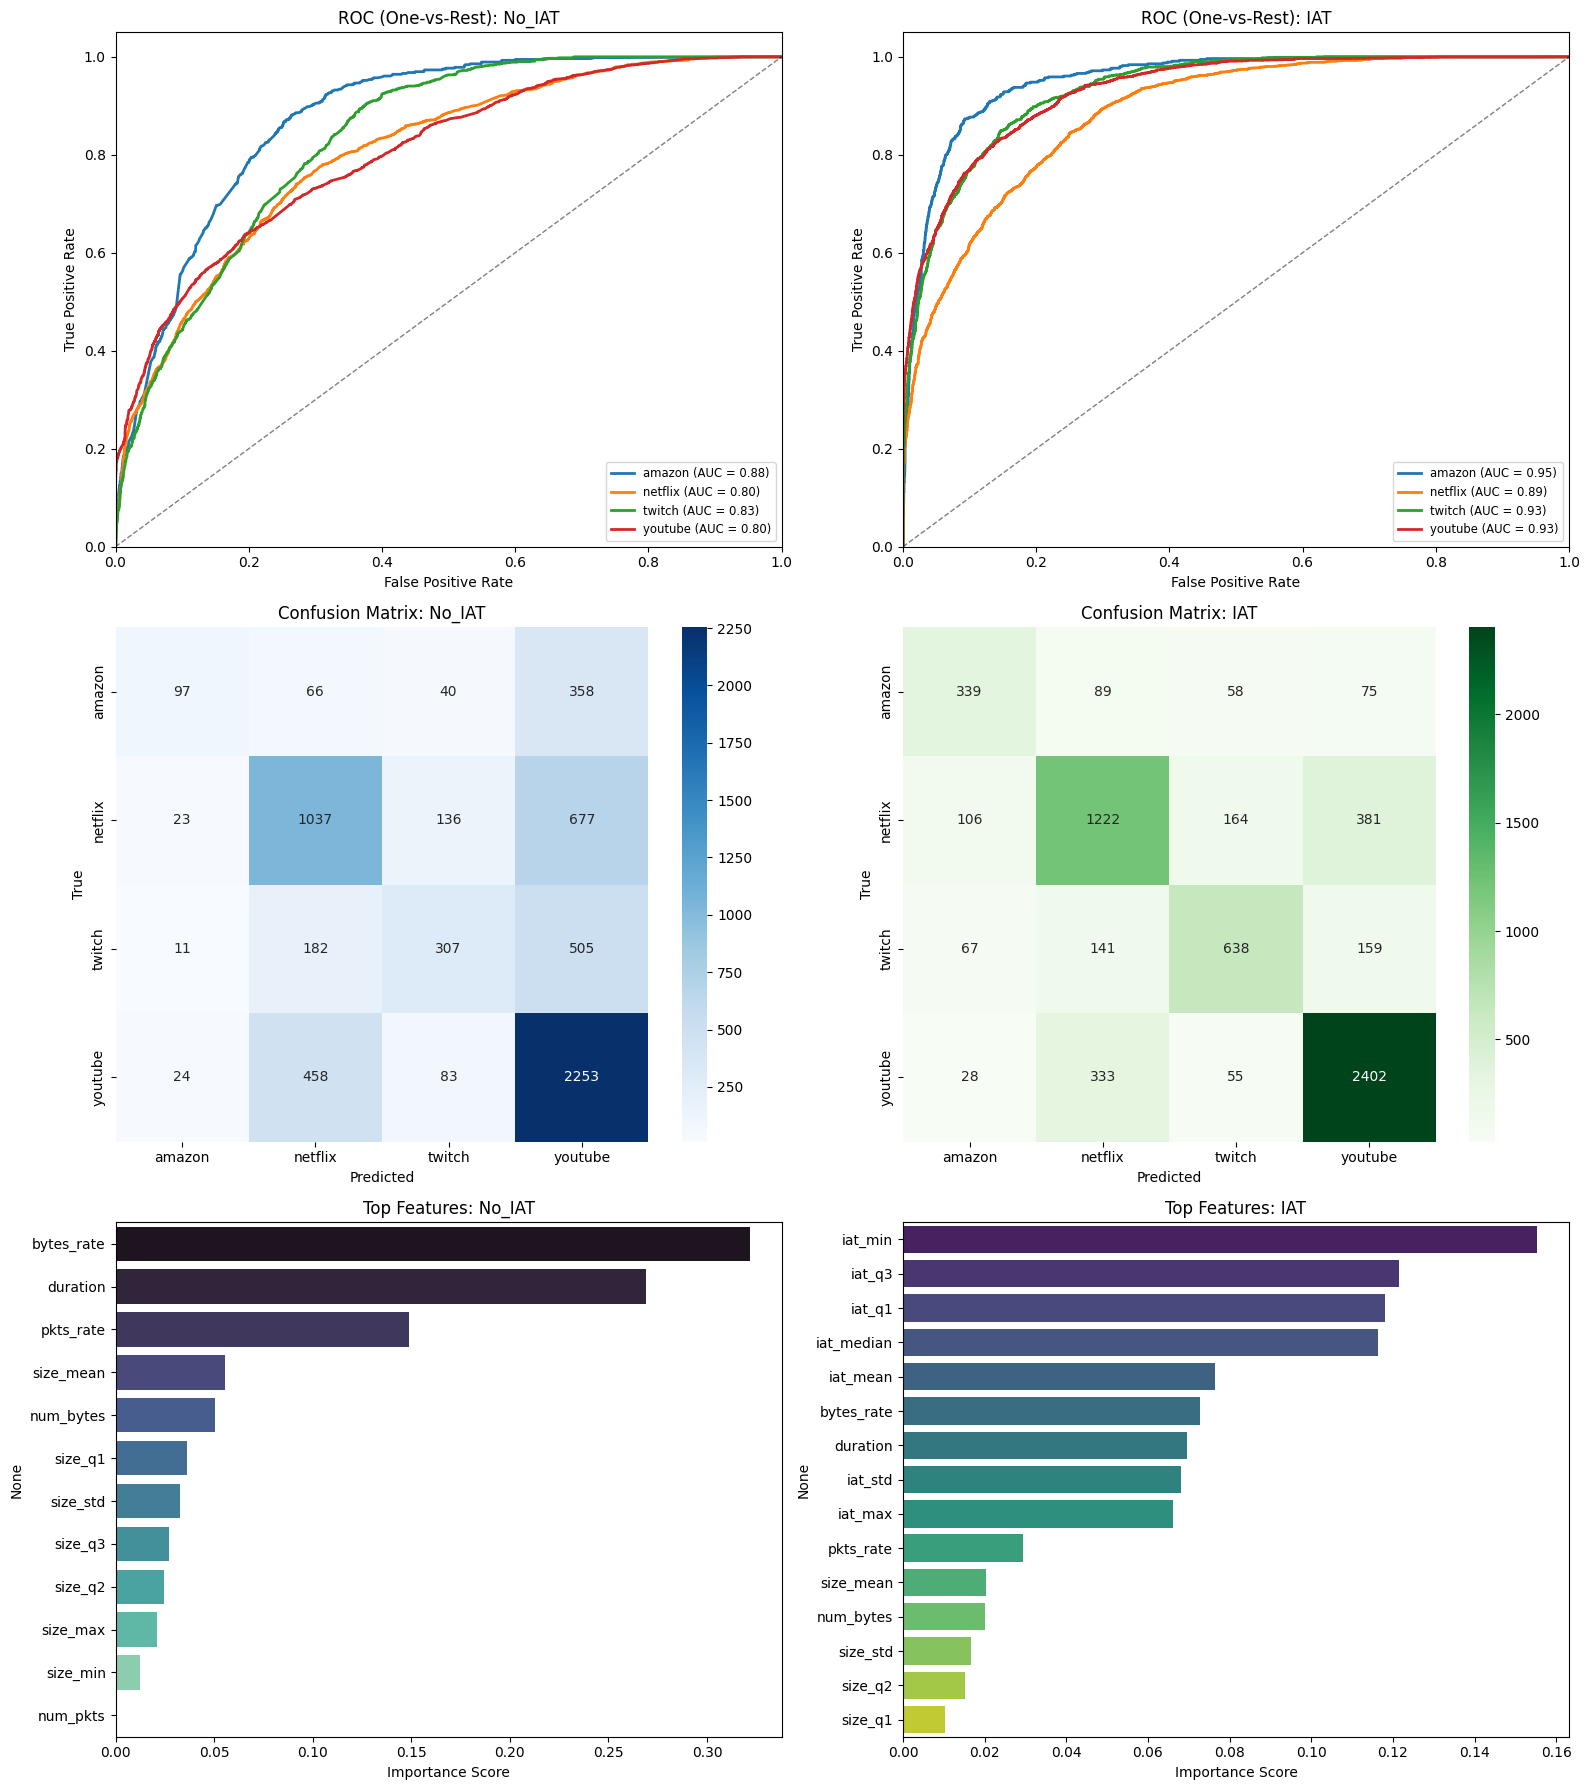

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix, 
    roc_auc_score, 
    precision_recall_fscore_support,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

# Computes statistics for the inputted model on the testing data
def get_stats(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)
    
    # Standard Metrics
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='weighted', zero_division=0
    )
    
    # Multi-Class AUC
    auc_ovr = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')
    auc_ovo = roc_auc_score(y_test, y_prob, multi_class='ovo', average='weighted')
    
    return {
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "AUC (OvR)": auc_ovr,
        "AUC (OvO)": auc_ovo
    }

# Plots One-vs-Rest ROC curves for the inputted model
def plot_multiclass_roc(model, X_test, y_test, model_name, ax):
    classes = model.classes_
    y_bin = label_binarize(y_test, classes=classes)
    y_score = model.predict_proba(X_test)
    n_classes = y_bin.shape[1]

    # Plot curve for each class
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2, label=f'{classes[i]} (AUC = {roc_auc:.2f})')

    # Random guess line
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC (One-vs-Rest): {model_name}')
    ax.legend(loc="lower right", fontsize='small')

# Plots feature importance for the inputted model
def plot_feature_importance(model, X_test, model_name, ax, color_palette='viridis'):
    # Get importance and sort
    importances = pd.Series(model.feature_importances_, index=X_test.columns)
    importances = importances.sort_values(ascending=False).head(15) # Top 15
    
    # Draw bar plot
    sns.barplot(
        x=importances,
        y=importances.index,
        hue=importances.index,
        palette=color_palette,
        legend=False,
        ax=ax
    )
    ax.set_title(f"Top Features: {model_name}")
    ax.set_xlabel("Importance Score")

# Run all evaluations using the above functions 
print("Calculating metrics...")

# Statistics
metrics_base = get_stats(rf_no_iat, X_test_no_iat, y_test_no_iat, "No_IAT")
metrics_iat = get_stats(rf_iat, X_test_iat, y_test_iat, "IAT")

# Create & Print Table
df_res = pd.DataFrame([metrics_base, metrics_iat])
print("\n" + "="*40)
print("FINAL METRICS COMPARISON")
print("="*40)
print(df_res.round(4))

# Plots
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# ROC curves
plot_multiclass_roc(rf_no_iat, X_test_no_iat, y_test_no_iat, "No_IAT", axes[0, 0])
plot_multiclass_roc(rf_iat, X_test_iat, y_test_iat, "IAT", axes[0, 1])

labels = sorted(y_test_no_iat.unique())

# NO_IAT confusion matrix
cm_base = confusion_matrix(y_test_no_iat, rf_no_iat.predict(X_test_no_iat), labels=labels)
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0], 
            xticklabels=labels, yticklabels=labels)
axes[1, 0].set_title("Confusion Matrix: No_IAT")
axes[1, 0].set_xlabel("Predicted")
axes[1, 0].set_ylabel("True")

# IAT confusion matrix
cm_iat = confusion_matrix(y_test_iat, rf_iat.predict(X_test_iat), labels=labels)
sns.heatmap(cm_iat, annot=True, fmt='d', cmap='Greens', ax=axes[1, 1], 
            xticklabels=labels, yticklabels=labels)
axes[1, 1].set_title("Confusion Matrix: IAT")
axes[1, 1].set_xlabel("Predicted")
axes[1, 1].set_ylabel("True")

# Feature importances
plot_feature_importance(rf_no_iat, X_test_no_iat, "No_IAT", axes[2, 0], 'mako')
plot_feature_importance(rf_iat, X_test_iat, "IAT", axes[2, 1], 'viridis')

# Display plots
plt.tight_layout()
plt.show()

Wow! As hypothesized, IAT statistics make a HUGE difference! Accuracy increased by over 13%, F1 score increased by ~0.17, and AUC increased by ~0.1. The IAT stats were also treated as significantly more important by the IAT model than the regular NetML STATS features. This shows the tremendous and statistically significant impact that IAT stats proivde.